Numba imported
73705


/home/skelly/school/spices/pytorch_implementation/double_gmm.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]
/home/skelly/school/spices/pytorch_implementation/double_gmm.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]


Cluster 0 Center: x=4101.35, y=4098.84
Cluster 1 Center: x=4100.02, y=4102.18
Cluster 0 Spread (Scaled Units): x_std=2.97, y_std=3.22, theta=75.85
Cluster 1 Spread (Scaled Units): x_std=0.92, y_std=2.36, theta=335.89
Background table should be larger than sources table.
Cluster 0 Center: x=4103.90, y=4095.72
Cluster 1 Center: x=4094.13, y=4100.42
Cluster 2 Center: x=4100.88, y=4098.30
Cluster 3 Center: x=4110.39, y=4100.38
Cluster 0 Spread (Scaled Units): x_std=1.82, y_std=2.33, theta=25.76
Cluster 1 Spread (Scaled Units): x_std=1.76, y_std=2.83, theta=354.27
Cluster 2 Spread (Scaled Units): x_std=2.86, y_std=2.92, theta=12.21
Cluster 3 Spread (Scaled Units): x_std=1.70, y_std=3.12, theta=359.04
Cluster 0 Center: x=4103.00, y=4107.57
Cluster 1 Center: x=4096.10, y=4096.04
Cluster 2 Center: x=4102.50, y=4111.85
Cluster 3 Center: x=4102.97, y=4093.05
Cluster 0 Spread (Scaled Units): x_std=0.97, y_std=1.25, theta=19.32
Cluster 1 Spread (Scaled Units): x_std=0.51, y_std=1.08, theta=95.32
C

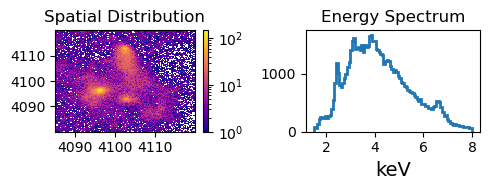

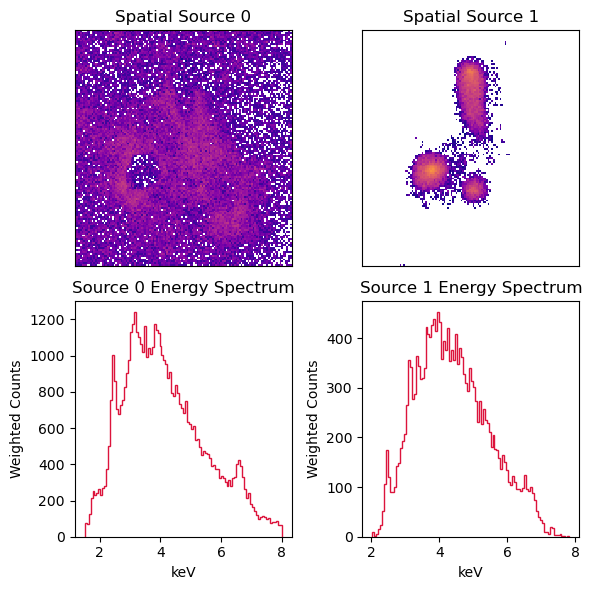

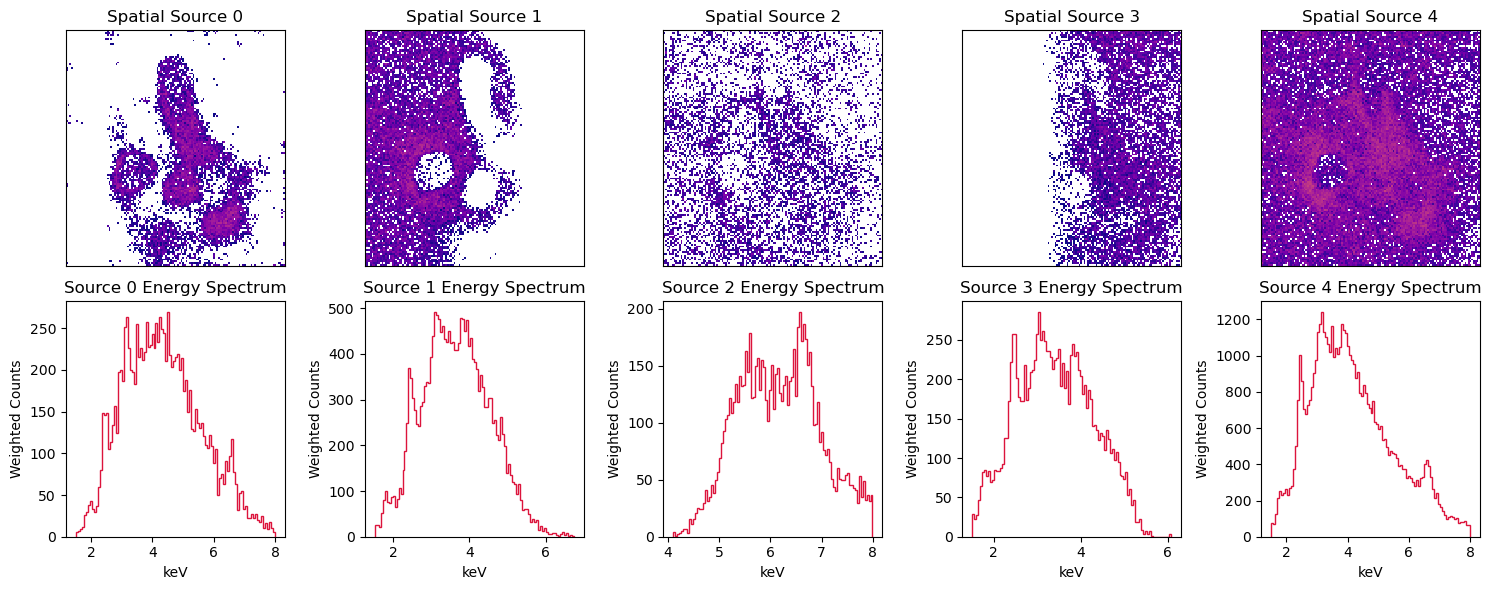

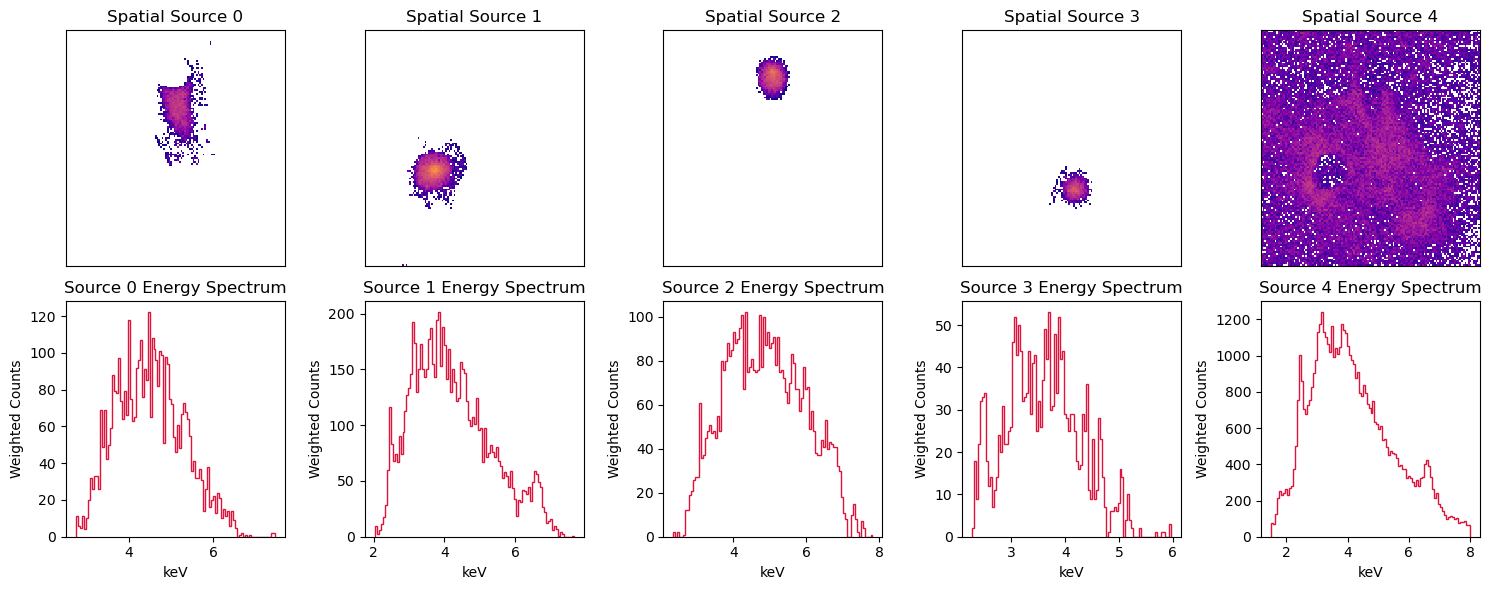

In [1]:
from double_gmm import *

In [2]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
def gaussian(x, y, x0, y0, xalpha, yalpha, A):
        return A * np.exp( -((x-x0)/xalpha)**2 -((y-y0)/yalpha)**2)

def _gaussian(M, *args):
    x, y = M
    arr = np.zeros(x.shape)
    for i in range(len(args)//5):
        arr += gaussian(x, y, *args[i*5:i*5+5])
    return arr

def fit_contours_2d(table):
    counts, xedges, yedges = np.histogram2d(
        table['x'], 
        table['y'], 
        bins=[BINX, BINY], 
        weights=table['energy']
    )

    # Calculate bin centers (this is where the data "lives" for the fit)
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)

    # Flatten the grid for curve_fit
    xdata_flat = np.vstack((X.ravel(), Y.ravel()))
    zdata_flat = counts.T.ravel()  # .T to align histogram (x,y) with meshgrid (y,x)

    # 4. Smart Initial Guesses (Heuristic)
    idx_max = np.argmax(zdata_flat)
    guess_x0 = xdata_flat[0, idx_max]
    guess_y0 = xdata_flat[1, idx_max]
    guess_A = np.max(counts)
    guess_sig = (x_centers.max() - x_centers.min()) / 10

    # Construct p0 for, say, 2 Gaussians (one at peak, one slightly offset)
    p0 = [guess_x0, guess_y0, guess_sig, guess_sig, guess_A,
        guess_x0+1, guess_y0+1, guess_sig, guess_sig, guess_A/2]

    # 5. The Fit
    # Using bounds to keep widths and amplitudes positive
    lower = [-np.inf, -np.inf, 0.1, 0.1, 0] * 2
    upper = [np.inf, np.inf, np.inf, np.inf, np.inf] * 2

    popt, pcov = curve_fit(_gaussian, xdata_flat, zdata_flat, p0=p0, bounds=(lower, upper))

    # 6. Visualization
    fit_grid = _gaussian(xdata_flat, *popt).reshape(BINY, BINX)


    individual_plot = False
    if individual_plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        # Plot Binned Data
        im1 = ax1.imshow(counts.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='plasma')
        ax1.set_title(f'Binned Energy ({BINX}x{BINY})')
        plt.colorbar(im1, ax=ax1)

        # Plot Fit Contours over Data
        ax2.imshow(counts.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='gray_r', alpha=0.5)
        cont = ax2.contour(X, Y, fit_grid, levels=20, cmap='plasma')
        ax2.set_title('Fitted Gaussians (Contours)')
        plt.colorbar(cont, ax=ax2)

        plt.show()
    
    return popt

def fit_contours_3d(table):

    # 1. Setup Bins (small for necessity)
    BINX, BINY, BINE = 32, 32, 32

    # 2. Create 3D Histogram (Voxels)
    # This counts how many 'events' fall into each 3D cube
    H, edges = np.histogramdd(
        table[['x', 'y', 'energy']].values, 
        bins=(BINX, BINY, BINE)
    )

    # Calculate bin centers for each axis
    centers = [(e[:-1] + e[1:]) / 2 for e in edges]
    X, Y, E = np.meshgrid(*centers, indexing='ij')

    # Flatten for curve_fit
    # Independent variables: (3, N_voxels)
    coords_flat = np.vstack((X.ravel(), Y.ravel(), E.ravel()))
    # Dependent variable: Density in that voxel
    density_flat = H.ravel()

    # 3. Define 3D Gaussian Model
    def gaussian_3d(coords, x0, y0, e0, sx, sy, se, A):
        x, y, e = coords
        inner = ( (x-x0)/sx )**2 + ( (y-y0)/sy )**2 + ( (e-e0)/se )**2
        return A * np.exp(-inner)

    # 4. Smart Initial Guess
    idx_max = np.argmax(density_flat)
    p0 = [
        coords_flat[0, idx_max], # x0
        coords_flat[1, idx_max], # y0
        coords_flat[2, idx_max], # e0
        np.std(table['x'])/2, # sx
        np.std(table['y'])/2, # sy
        np.std(table['energy'])/2, # se
        np.max(density_flat)     # A
    ]

    # 5. Perform the Fit
    # Constraints: Widths and Amplitude must be positive
    bounds = ([-np.inf, -np.inf, -np.inf, 0.1, 0.1, 0.1, 0], [np.inf]*7)

    popt, _ = curve_fit(gaussian_3d, coords_flat, density_flat, p0=p0, bounds=bounds)

    print("Fitted Center (x, y, energy):", popt[:3])
    print("Fitted Sigmas (sx, sy, se):", popt[3:6])

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Plot the Raw Data (as a Voxel "Cloud")
    # We only plot bins that have a significant amount of energy to keep it clean
    threshold = np.max(H) * 0.1
    x_idx, y_idx, e_idx = np.where(H > threshold)

    # Convert indices back to actual coordinates for plotting
    sc = ax.scatter(
        X[x_idx, y_idx, e_idx], 
        Y[x_idx, y_idx, e_idx], 
        E[x_idx, y_idx, e_idx], 
        c=H[x_idx, y_idx, e_idx], 
        cmap='viridis', 
        alpha=0.2, 
        s=20,
        label='Binned Data'
    )

    # 2. Plot the Fitted "Blob" Center
    ax.scatter(popt[0], popt[1], popt[2], color='red', s=100, marker='*', label='Fit Center')

    # 3. Plot 3D Error Bars (representing the Sigmas/Spread)
    # This shows the "extent" of the Gaussian in each dimension
    ax.plot([popt[0]-popt[3], popt[0]+popt[3]], [popt[1], popt[1]], [popt[2], popt[2]], color='red', lw=2)
    ax.plot([popt[0], popt[0]], [popt[1]-popt[4], popt[1]+popt[4]], [popt[2], popt[2]], color='red', lw=2)
    ax.plot([popt[0], popt[0]], [popt[1], popt[1]], [popt[2]-popt[5], popt[2]+popt[5]], color='red', lw=2)

    # 4. Optional: Add a "Wireframe" of the Gaussian at 1-Sigma
    # We create a low-res sphere and transform it into the fitted ellipsoid
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    xs = popt[3] * np.cos(u) * np.sin(v) + popt[0]
    ys = popt[4] * np.sin(u) * np.sin(v) + popt[1]
    es = popt[5] * np.cos(v) + popt[2]
    ax.plot_wireframe(xs, ys, es, color="red", alpha=0.5, linewidth=0.5)

    # Labels and styling
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Energy')
    ax.set_title('3D Gaussian Blob Fit Visualization')
    plt.colorbar(sc, ax=ax, label='Energy Density', shrink=0.6)
    ax.legend()

    plt.show()

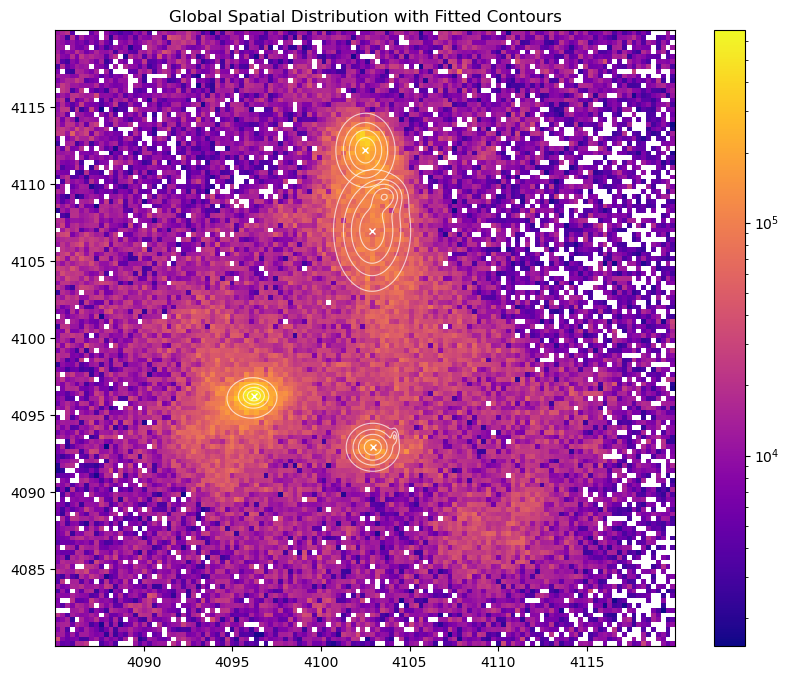

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.optimize import curve_fit

fig, ax1 = plt.subplots(figsize=(10, 8))

# 1. Plot the Global Background (All data)
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 weights=subset['energy'],
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Global Spatial Distribution with Fitted Contours')
fig.colorbar(h2d[3], ax=ax1)

# 2. Loop through your sources and overlay contours
for choice in range(len(split_sources)):
    table = split_sources[choice]
    
    # --- Re-use your fitting logic here (or call your function) ---
    # Note: We need the fit_grid and the X, Y meshgrid for the contour function
    popt = fit_contours_2d(table)
    counts, xedges, yedges = np.histogram2d(
        table['x'], table['y'], 
        bins=[BINX, BINY], weights=table['energy']
    )
    
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    
    # Flatten and fit (Simplified for 1 Gaussian per source for clarity)
    xdata_flat = np.vstack((X.ravel(), Y.ravel()))
    zdata_flat = counts.T.ravel()
    
    # ... (Insert your p0, bounds, and curve_fit logic here) ...
    # popt, _ = curve_fit(_gaussian, xdata_flat, zdata_flat, p0=p0, bounds=(lower, upper))
    
    # Generate the fitted surface
    fit_grid = _gaussian(xdata_flat, *popt).reshape(len(y_centers), len(x_centers))

    # 3. Overlay the Contour
    # We use the X and Y meshgrids to tell matplotlib exactly where the 'fit_grid' sits
    cont = ax1.contour(X, Y, fit_grid, levels=5, colors='white', linewidths=0.8, alpha=0.7)
    
    # Optional: Plot the fitted center point
    ax1.plot(popt[0], popt[1], 'wx', markersize=5)

plt.show()

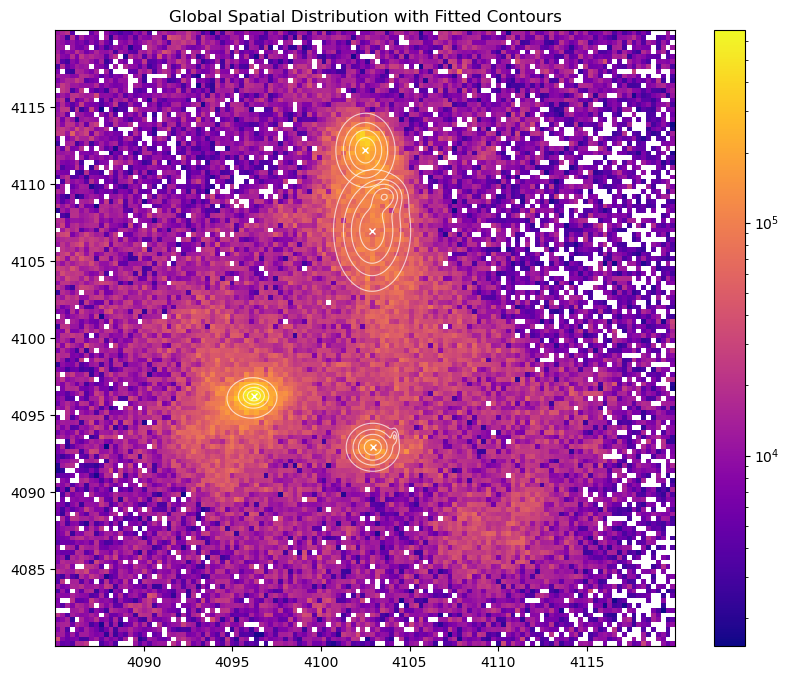


Source 0 Analysis:
  Ring (np.float64(0.0), np.float64(2500.0)): Weighted Energy Sum = 0.00
  Ring (np.float64(2500.0), np.float64(5000.0)): Weighted Energy Sum = 3429733.58
  Ring (np.float64(5000.0), np.float64(7500.0)): Weighted Energy Sum = 3686315.33
  Ring (np.float64(7500.0), np.float64(10000.0)): Weighted Energy Sum = 4048840.57
  Ring (np.float64(10000.0), np.float64(12500.0)): Weighted Energy Sum = 3787044.04
  Ring (np.float64(12500.0), np.float64(15000.0)): Weighted Energy Sum = 96826.63

Source 1 Analysis:
  Ring (np.float64(0.0), np.float64(20000.0)): Weighted Energy Sum = 0.00
  Ring (np.float64(20000.0), np.float64(40000.0)): Weighted Energy Sum = 7580455.13
  Ring (np.float64(40000.0), np.float64(60000.0)): Weighted Energy Sum = 3855662.31
  Ring (np.float64(60000.0), np.float64(80000.0)): Weighted Energy Sum = 2955874.41
  Ring (np.float64(80000.0), np.float64(100000.0)): Weighted Energy Sum = 2685369.52

Source 2 Analysis:
  Ring (np.float64(0.0), np.float64(1500.0)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.path import Path

# --- Helper Function for Masking ---
def get_mask(collection, shape, nodes):
    mask = np.zeros(shape, dtype=bool)
    for path in collection.get_paths():
        # contains_points is the engine that finds pixels inside the contour
        grid_included = path.contains_points(nodes)
        mask |= grid_included.reshape(shape)
    return mask

fig, ax1 = plt.subplots(figsize=(10, 8))

# 1. Plot the Global Background (All data)
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 weights=subset['energy'],
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Global Spatial Distribution with Fitted Contours')
fig.colorbar(h2d[3], ax=ax1)

# List to store results for all sources
all_source_results = []

# 2. Loop through your sources and overlay contours
for choice in range(len(split_sources)):
    table = split_sources[choice]
    
    # Generate histogram for fitting
    counts, xedges, yedges = np.histogram2d(
        table['x'], table['y'], 
        bins=[BINX, BINY], weights=table['energy']
    )
    
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    
    # Flatten for curve_fit
    xdata_flat = np.vstack((X.ravel(), Y.ravel()))
    zdata_flat = counts.T.ravel()
    
    # Fitting logic (Assumes _gaussian and fit_contours_2d are defined)
    popt = fit_contours_2d(table) 
    fit_grid = _gaussian(xdata_flat, *popt).reshape(len(y_centers), len(x_centers))

    # 3. Overlay the Contour
    # Levels=5 gives us 5 rings (from outermost to innermost)
    cont = ax1.contour(X, Y, fit_grid, levels=5, colors='white', linewidths=0.8, alpha=0.7)
    ax1.plot(popt[0], popt[1], 'wx', markersize=5)

    # --- INTEGRATED WEIGHTED SUM LOGIC ---
    nodes = np.column_stack((X.flatten(), Y.flatten()))
    
    # Pre-calculate masks for this source's levels
    masks = []
    all_paths = cont.get_paths()

    for i in range(len(cont.levels)):
        mask = np.zeros(X.shape, dtype=bool)
        path = all_paths[i]
        grid_included = path.contains_points(nodes)
        mask |= grid_included.reshape(X.shape)
        masks.append(mask)
    
    source_ring_sums = []
    # Calculate ring sums (Outer Mask - Inner Mask)
    for i in range(len(masks) - 1):
        outer_mask = masks[i]
        inner_mask = masks[i+1]
        ring_mask = outer_mask & ~inner_mask
        
        # Weighted sum: use the current source's energy grid
        # Note: We use counts (the binned energy) or your raw table data mapped to the grid
        weighted_sum = np.sum(counts.T[ring_mask]) 
        
        level_range = (cont.levels[i], cont.levels[i+1])
        source_ring_sums.append({'levels': level_range, 'sum': weighted_sum})
    
    all_source_results.append({'source_id': choice, 'rings': source_ring_sums})

plt.show()

# Example: Accessing the data after plotting
for res in all_source_results:
    print(f"\nSource {res['source_id']} Analysis:")
    for ring in res['rings']:
        print(f"  Ring {ring['levels']}: Weighted Energy Sum = {ring['sum']:.2f}")

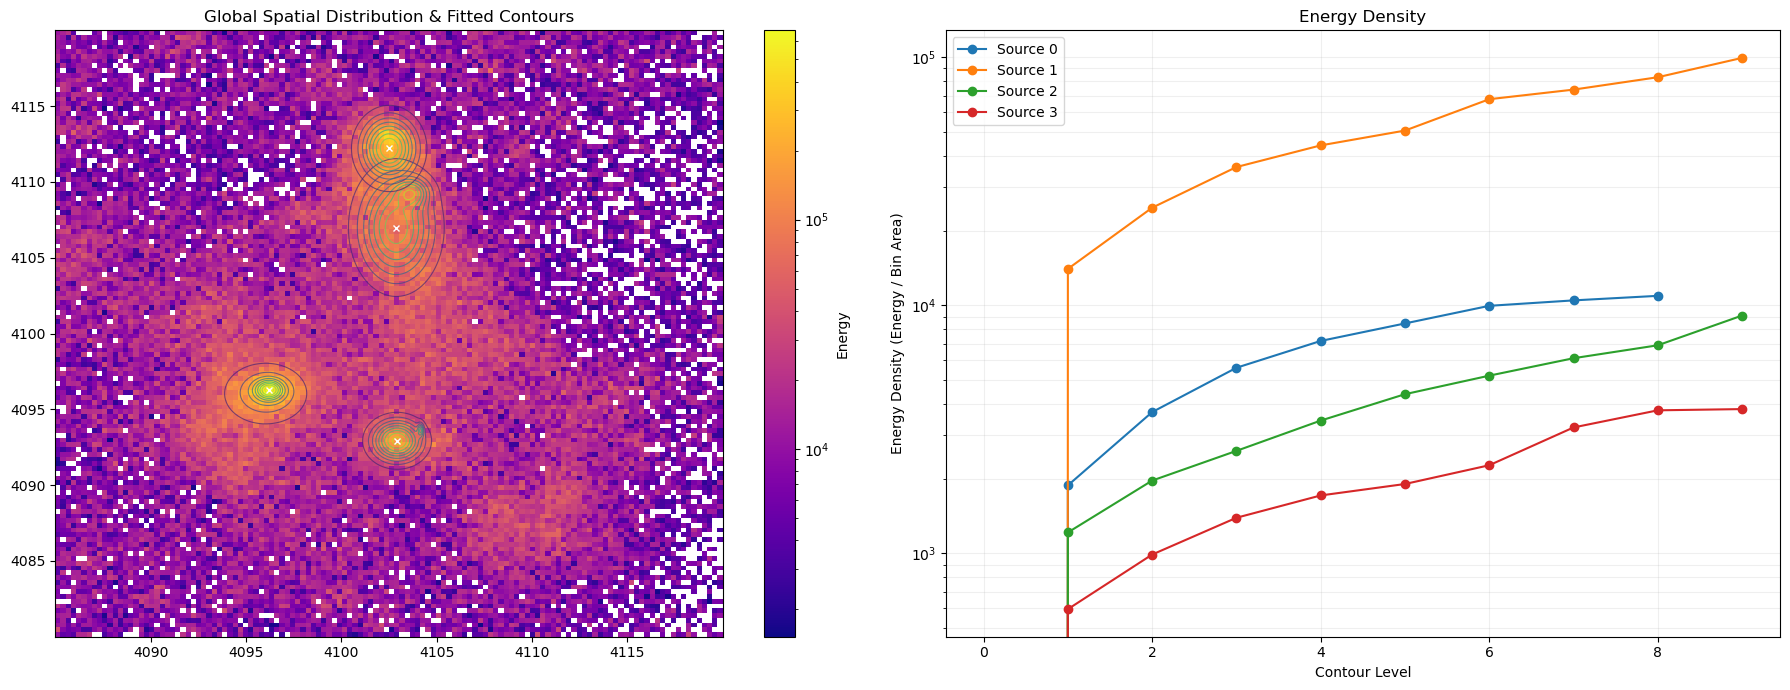

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.path import Path

# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 1. Plot Global Background on ax1
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 weights=subset['energy'],
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Global Spatial Distribution & Fitted Contours')
fig.colorbar(h2d[3], ax=ax1, label='Energy')

all_source_results = []

for choice in range(len(split_sources)):
    table = split_sources[choice]
    
    # Histogram & Fit (Same as your logic)
    counts, xedges, yedges = np.histogram2d(
        table['x'], table['y'], 
        bins=[BINX, BINY], weights=table['energy']
    )
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    
    popt = fit_contours_2d(table) 
    xdata_flat = np.vstack((X.ravel(), Y.ravel()))
    fit_grid = _gaussian(xdata_flat, *popt).reshape(len(y_centers), len(x_centers))

    # 3. Plot Contours on ax1
    cont = ax1.contour(X, Y, fit_grid, levels=10, linewidths=0.8, alpha=0.7)
    ax1.plot(popt[0], popt[1], 'wx', markersize=5)

    # --- MASKING LOGIC ---
    nodes = np.column_stack((X.flatten(), Y.flatten()))
    masks = []
    all_paths = cont.get_paths()

    for i in range(len(cont.levels)):
        mask = np.zeros(X.shape, dtype=bool)
        if i < len(all_paths):
            grid_included = all_paths[i].contains_points(nodes)
            mask = grid_included.reshape(X.shape)
        masks.append(mask)
    
    densities = []
    mid_levels = []

    for i in range(len(masks) - 1):
        ring_mask = masks[i] & ~masks[i+1]
        
        # Calculate Density: Sum of Energy / Number of Bins in ring
        total_energy = np.sum(counts.T[ring_mask])
        area = np.sum(ring_mask) # Count of True pixels
        
        # Avoid division by zero if ring is too thin
        density = total_energy / area if area > 0 else 0
        
        densities.append(density)
        mid_levels.append(i) # Use the starting level for X-axis

    # 4. Plot Energy Density on ax2
    ax2.plot(mid_levels, densities, 'o-', label=f'Source {choice}')
    all_source_results.append(densities)

# Finalize ax2 (Density Plot)
ax2.set_title('Energy Density')
ax2.set_xlabel('Contour Level')
ax2.set_ylabel('Energy Density (Energy / Bin Area)')
ax2.set_yscale('log') # Usually helpful for energy distributions
ax2.grid(True, which="both", ls="-", alpha=0.2)
ax2.legend()

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from matplotlib.path import Path



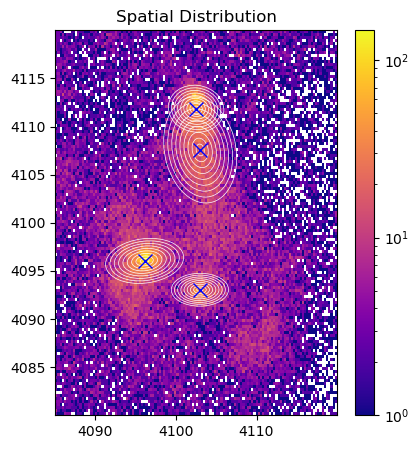

In [7]:
from matplotlib.patches import Ellipse
fig = plt.figure(figsize=(10, 5)) 
ax1 = fig.add_subplot(1, 2, 1)
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Spatial Distribution')
fig.colorbar(h2d[3], ax=ax1)

for choice in range(4):
    src = split_sources[choice]
    src_center = centers[choice]
    src_std_dev = std_dev[choice]

    ax1.plot(src_center[0], src_center[1], 'bx', markersize=10, label='Center')
    for i in range(10):
        ellipse = Ellipse(xy=src_center, width=src_std_dev[0] * i, height=src_std_dev[1] * i,
                                angle = src_std_dev[2], edgecolor='w', fc='None', lw=0.5)
        ax1.add_patch(ellipse)


In [8]:
def generate_elliptical_profile(df, center, widths, angle_deg, num_bins=10):
    # 1. Setup coordinates relative to center
    dx = df['x'] - center[0]
    dy = df['y'] - center[1]
    
    # 2. Rotate coordinates to align with ellipse axes
    theta = np.radians(-angle_deg)
    x_rot = dx * np.cos(theta) - dy * np.sin(theta)
    y_rot = dx * np.sin(theta) + dy * np.cos(theta)
    
    # 3. Calculate "Elliptical Radius" 
    # This radius = 1.0 at the boundary of the ellipse defined by 'widths'
    # width/2 and height/2 represent the semi-axes (1-sigma)
    r_ell = np.sqrt((x_rot / (widths[0]))**2 + (y_rot / (widths[1]))**2)
    
    # 4. Binning
    # We'll use the 'i' from your loop as the bin index
    df['ell_bin'] = np.digitize(r_ell, bins=np.arange(num_bins + 1))
    
    # 5. Aggregate Energy
    df['weighted_energy'] = df['energy'] * df['weight']
    profile = df.groupby('ell_bin')['weighted_energy'].sum().reset_index()
    
    return profile

In [9]:
def generate_normalized_profile(df, center, widths, angle_deg, num_bins=10, prec=5.0):
    # --- 1. Calculate the Elliptical Radius ---
    dx = df['x'] - center[0]
    dy = df['y'] - center[1]
    theta = np.radians(-angle_deg)
    x_rot = dx * np.cos(theta) - dy * np.sin(theta)
    y_rot = dx * np.sin(theta) + dy * np.cos(theta)
    
    # Radii normalized to the prec-sigma widths 
    # (so when we go num_bins sigma out, we're acutally going num_bins / prec sigma out)
    r_ell = np.sqrt((x_rot / widths[0])**2 + (y_rot / widths[1])**2) * prec

    # --- 2. Binning ---
    bins = np.arange(num_bins + 1)
    df['ell_bin'] = np.digitize(r_ell, bins=bins)
    
    # --- 3. Aggregate Energy ---
    df['weighted_energy'] = df['energy']
    if 'weight' in df.columns:
        df['weighted_energy'] *= df['weight']
    
    profile = df.groupby('ell_bin')['weighted_energy'].sum().reset_index()
    
    # --- 4. Calculate Area of each Elliptical Annulus ---
    # Area of ellipse i: Pi * (a * i) * (b * i) = Pi * a * b * i^2
    def get_area(sigma_level):
        return np.pi * widths[0] * widths[1] * (sigma_level**2)

    areas = []
    for b in profile['ell_bin']:
        area_outer = get_area(b)
        area_inner = get_area(b - 1)
        areas.append(area_outer - area_inner)
    
    profile['area'] = areas
    profile['energy_density'] = profile['weighted_energy'] / profile['area']
    
    return profile

/tmp/ipykernel_2182/4287771349.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ell_bin'] = np.digitize(r_ell, bins=bins)
/tmp/ipykernel_2182/4287771349.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['weighted_energy'] = df['energy']
/tmp/ipykernel_2182/4287771349.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

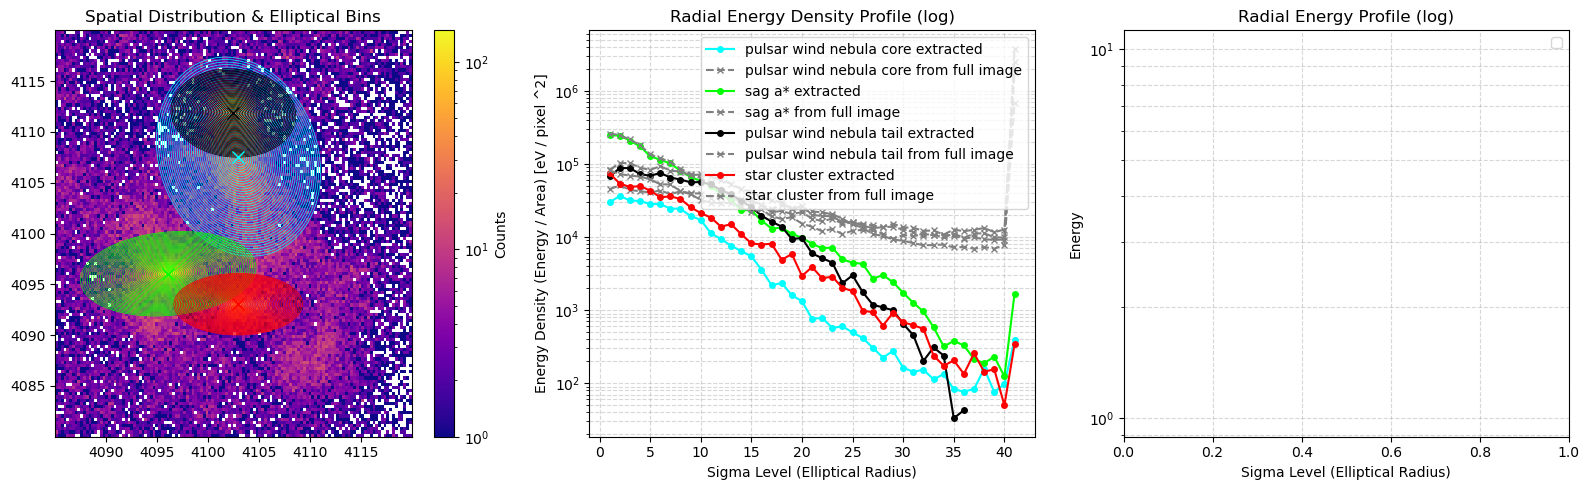

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse

# Setup the figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# 1. Plot the background 2D Histogram on ax1
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Spatial Distribution & Elliptical Bins')
fig.colorbar(h2d[3], ax=ax1, label='Counts')

# Define a color palette for the 4 sources
colors = ['cyan', 'lime', 'black', 'red']
source_names = ['pulsar wind nebula core', 'sag a*', 'pulsar wind nebula tail', 'star cluster']

for choice in range(4):
    src = split_sources[choice]
    src_center = centers[choice]
    src_std_dev = std_dev[choice] # [std_x, std_y, angle]
    color = colors[choice]

    # --- Generate the Normalized Profile ---
    prec = 5.0
    num_bins = 40
    profile = generate_normalized_profile(src, src_center, src_std_dev[:2], src_std_dev[2], num_bins=num_bins, prec=prec)
    profile_base = generate_normalized_profile(subset, src_center, src_std_dev[:2], src_std_dev[2], num_bins=num_bins, prec=prec)
    
    ax1.plot(src_center[0], src_center[1], marker='x', color=color, markersize=8)
    
    for i in range(1, num_bins + 1):
        ellipse = Ellipse(xy=src_center, 
                          width=src_std_dev[0] * 2 * i / prec, 
                          height=src_std_dev[1] * 2 * i / prec,
                          angle=src_std_dev[2], 
                          edgecolor=color, fc='None', lw=0.5)
        ax1.add_patch(ellipse)

    ax2.plot(profile['ell_bin'], profile['energy_density'], 
             marker='o', markersize=4, linestyle='-', 
             color=color, label=f'{source_names[choice]} extracted')
    ax2.plot(profile_base['ell_bin'], profile_base['energy_density'], 
             marker='x', markersize=4, linestyle='--', 
             color='gray', label=f'{source_names[choice]} from full image')

# Final formatting for the Profile Plot
ax2.set_title('Radial Energy Density Profile (log)')
ax2.set_xlabel('Sigma Level (Elliptical Radius)')
ax2.set_ylabel('Energy Density (Energy / Area) [eV / pixel ^2]')
ax2.set_yscale('log')
ax2.grid(True, which="both", linestyle='--', alpha=0.5)
ax2.legend()
ax3.set_title('Radial Energy Profile (log)')
ax3.set_xlabel('Sigma Level (Elliptical Radius)')
ax3.set_yscale('log')
ax3.set_ylabel('Energy')
ax3.grid(True, which="both", linestyle='--', alpha=0.5)
ax3.legend()

plt.tight_layout()
plt.show()